# Adaptive Thiele Continued Fractions #

This Jupyter notebook contains Maple code (licensed by the MIT license below) to explore the use of the Adaptive Thiele Continued Fraction method of rational approximation to approximate the Lambert $W$ function near the branch point using 
\begin{equation}
f(s) = \left\{\begin{array}{cc}
W_0\left(-\exp(-1)(1-s^2/2)\right) & s \ge 0
\\
W_{-1}\left(-\exp(-1)(1-s^2/2)\right) & s < 0  
\end{array}\right.
\end{equation}

© Robert M. Corless 2026 (MIT Release licence)

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


### Translation of Oliver Salazar Celis' Matlab code ###
### from https://github.com/oscelis/tcf/blob/main/tcf.m ###
### Translation by Robert M Corless July 2026 ###

Two auxiliary procedures initially translated by Gemini but corrected by RMC.

In [1]:
# Gemini's translation of prz_cfrac, with many errors fixed 
# and the logic of k changed
# 
# Note that it returns poles, zeros, residues
# so I have changed the name to pzr_cfrac
pzr_cfrac := proc(aa::Vector, zz::Vector, ss::Vector, 
                 {bal::truefalse := true}, 
                 {k::posint := numelems(aa)})
    local C, Dp, dt, pol, zer, res, Dl, Dr, Dz, iter, T1, T2, dz, pz, i, j, vz;
    uses LinearAlgebra;

  if Digits > 15 then
    dt := complex(float);
  else
    dt := complex(float[8]);
  end if;

    # --- POLES CALCULATION ---
    # C is a (k-1) x (k-1) matrix with superdiagonal -ss[2..(k-1)]
    C := Matrix(k-1, k-1, datatype=dt, 0 );
    for i from 1 to k-2 do
        C[i, i+1] := -ss[i+1];
    end do;

    # Dp is a (k-1) x (k-1) tridiagonal-like matrix
    Dp := Matrix(k-1, k-1, datatype=dt, 0);
    for i from 1 to k-1 do
        Dp[i, i] := aa[i+1]; # main diagonal aa[2..k]
    end do;
    for i from 1 to k-2 do
        Dp[i, i+1] := -ss[i+1] * zz[i+1]; # superdiagonal
        Dp[i+1, i] := -1;                  # subdiagonal
    end do;

    if not bal then
        pol := Eigenvalues(Dp, C);
    else
        # Call the previously defined baleig procedure
        Dl, Dr, iter := baleig(Dp, C, 5);
        T1 := DiagonalMatrix(Vector(k-1, i -> 1.0 / Dl[i]));
        T2 := DiagonalMatrix(Dr);
        pol := Eigenvalues(T1 . Dp . T2, T1 . C . T2);
    end if;
    # Filter out infinity values if any are present
    pol := Vector( select( t->type(t,complex(numeric)), convert(pol,list) ) );


    # --- ZEROS CALCULATION ---
    # C is a k x k matrix with superdiagonal -ss[1..(k-1)]
    C := Matrix(k, k, datatype=complex(float), 0);
    for i from 1 to k-1 do
        C[i, i+1] := -ss[i];
    end do;

    # Dz is a k x k matrix
    Dz := Matrix(k, k, datatype=dt, 0);
    for i from 1 to k do
        Dz[i, i] := aa[i]; # main diagonal aa[1..k]
    end do;
    for i from 1 to k-1 do
        Dz[i, i+1] := -ss[i] * zz[i]; # superdiagonal
        Dz[i+1, i] := -1;              # subdiagonal
    end do;

    if not bal then
        zer := Eigenvalues(Dz, C);
    else
        Dl, Dr, iter := baleig(Dz, C, 5);
        T1 := DiagonalMatrix(Vector(k, i -> 1.0 / Dl[i]));
        T2 := DiagonalMatrix(Dr);
        zer := Eigenvalues(T1 . Dz . T2, T1 . C . T2);
    end if;
    zer := Vector( select( t->type(t,complex(numeric)), convert(zer,list) ) );


    # --- RESIDUES CALCULATION ---
    res := Vector(Dimension(pol), datatype=dt, 0); # undefined behaves like NaN
    
    # 4-point complex circle step for approximate limit computation
    dz := Vector(4, j -> Float(1,-2-floor(Digits/4)) * exp(2.0 * I * Pi * j / 4.0));
    
    # Loop over each pole to calculate the residue
    for i from 1 to Dimension(pol) do
        pz := Vector(4, j -> pol[i] + dz[j]);
        
        # Evaluate the continued fraction at the 4 points
        vz := evalcfrac_unrolled(aa,zz,ss,pz);
        res[i] := 0;
        for j from 1 to 4 do
            res[i] := res[i] + vz[j] * dz[j];
        end do;
        res[i] := res[i] / 4.0;
    end do;

    return pol, zer, res;
end proc:

# Gemini's version of baleig, fixed up manually
baleig := proc(A::Matrix, B::Matrix, max_iter::integer)
    local n, Dl, Dr, dt, M, iter, i, j, emax, emin, d, e;
    uses LinearAlgebra;

  if Digits > 15 then
    dt := complex(float);
  else
    dt := complex(float[8]);
  end if;

    n := RowDimension(A);
    
    # Initialize scaling vectors as row vectors of ones
    Dl := Vector[row](n, datatype=dt, 1);
    Dr := Vector[row](n, datatype=dt, 1);
    
    # M = abs(A)^2 + abs(B)^2 element-wise
    M := Matrix(n, n, datatype=dt, (i,j) -> abs(A[i,j])^2 + abs(B[i,j])^2);

    for iter from 1 to max_iter do
        emax := 0;
        emin := 0;
        
        # Row scaling
        for i from 1 to n do
            # Compute row sum
            d := add(M[i,j],j=1..n);
            
            if d = 0 then
                e := 0;
            else
                e := -round(log[2](abs(d)) / 2);
            end if;
            
            # Scale the row of M by 2^(2*e)
            for j to n do
              M[i,j] := M[i,j]*2^(2*e);
            end do;
            
            # Update Dl
            Dl[i] := Dl[i] * 2^(-e);
            
            # Update bounds
            if e > emax then emax := e; end if;
            if e < emin then emin := e; end if;
        end do;
        
        # Column scaling
        for i from 1 to n do
            # Compute column sum
            d := add(M[j, i], j=1..n);
            
            if d = 0 then
                e := 0;
            else
                e := -round(log[2](abs(d)) / 2);
            end if;
            
            # Scale the column of M by 2^(2*e)
            for j to n do
              M[j, i] := M[j,i] * 2^(2*e);
            end do;
            
            # Update Dr
            Dr[i] := Dr[i] * 2^e;
            
            # Update bounds
            if e > emax then emax := e; end if;
            if e < emin then emin := e; end if;
        end do;
        
        # Stop if norms are all between 1/2 and 2
        if emax <= emin + 2 then
            break;
        end if;
    end do;

    # Return multiple values as a sequence
    return Dl, Dr, iter;
end proc:

kilobytes used=3520, alloc=9776, time=0.50

Compiler-compatible version (restricted to real data for the moment)

In [2]:
# m = dimension of input vectors f and x
# f = vector float[8] of function values
# x = vector float[8] of interpolation nodes
# tmp = vector float[8] size m temporary work space
# aa = vector float[8] of size nmax reciprocal differences on output
# ss = vector float[8] of size nmax scale factors on output
# ff = vector float[8] of size nmax chosen function values on output
# zz = vector float[8] of size nmax 
#             chosen interpolation nodes on output
#
# tol = positive float, usually 1.0e-13
# k  = dimension of aa,ss,ff,zz on output
# eqtm = 1 if scaling is to be done
tcf_toc := proc(m::integer[4], f::Vector(datatype=float[8]), 
                               x::Vector(datatype=float[8]), 
                   tmp::Vector(datatype=float[8]), 
                   skip::Vector(datatype=float[8]),
                   aa::Vector(datatype=float[8]), 
                   ss::Vector(datatype=float[8]), 
                   phi::Vector(datatype=float[8]), 
                   zz::Vector(datatype=float[8]), 
                   err::Vector(datatype=float[8]), 
                   tol::float[8], 
                   kay::Vector(1,datatype=float[8]), 
                   eqtm::integer[4] )
  local abstol, alpha, bigf, dt, e, i, j, k, ell, imin, imax, mindist, minf, 
        nmax, normf, skipj, tv ;
  #
  # Hardcoded workspace sizes
  #
  nmax := 250;

  minf := abs(f[1]);
  normf := minf;
  imin := 1;
  imax := 1;
  for i from 2 to m do
    tv := abs(f[i]);
    if tv > normf then
      imax := i;
      normf := tv;
    elif tv < minf then
      imin := i;
      minf := tv;
    end if;
  end do;
  
  abstol := tol*normf;   # Absolute tolerance

    for k to min(nmax,m) do # main loop
        if k=1 then # initialize
            i := imin; #smallest value
            skip[1] := i;
            aa[1] := f[i]; # ss[1] = 1
            # find imax for next step
            bigf := -1.0;
            for j to m do
              tv := abs(f[j]-aa[1]); # constant approx
              if j<>i and tv > bigf then
                imax := j;
                bigf := tv;
              end if;
            end do;
        else
          # i was found the previous loop: location max diff
          i := imax;
          #adaptive choice
          # inline aa[k] := inv_diff_cfrac_compiled(aa,zz,ss,x[i],f[i],k-1); 
          tv := f[i];
          for j to k-1 do
            tv := (ss[j]*x[i]-ss[j]*zz[j])/(tv-aa[j]);
          end do;
          aa[k] := tv;
          if abs(eqtm-1)<1/2 then # apply equivalence transformation
            alpha := 1/2;
            mindist := evalf( exp(-2*Pi*sqrt(k)/sqrt(alpha)) );
            e := 1/(abs(aa[k-1]*aa[k])+mindist);
            ss[k-1] := exp(ln(2)*round(ln(e)/ln(2))); # pow2(1,round(log2(e)));
          end if;
          aa[k] := aa[k]*ss[k-1];
        end if;
        zz[k] := x[i]; # store chosen node
        phi[k] := f[i];
        # 
        # inline evalhfcfrac_compiled(aa,zz,ss,x,tmp, k, m);
        # Initialize
        for j to m do
          tmp[j] := 0.0;
        end do;
        # main body of continued fraction
        for ell from k by -1 to 2 do
          for j to m do
            tmp[j] :=  ss[ell-1]*(x[j]-zz[ell-1])/(aa[ell]+tmp[j]);
          end do;
        end do;
        # constant term of continued fraction
        for j to m do
          tmp[j] := aa[1]+tmp[j];
        end do;

        bigf := -1;
        for j to m do
          # check if node j already processed
          # and is recorded in skip array
          # in 1 <= ell <= k-1
          skipj := 0;
          for ell to k-1 do
            if skip[ell]=j then 
              skipj := 1;
            end if;
          end do;
          # If j is not to be skipped, then
          # check if max difference occurs
          # at j
          if skipj = 0 then
            tv := abs(tmp[j]-f[j]);
            if tv>bigf then
              bigf := tv;
              imax := j;
            end if;
          end if;
        end do;
        skip[k] := imax;
        err[k] := bigf;
        if err[k] <= abstol then
          kay[1] := k;
          break
        end if;
    end do;
end proc:
# up to the user to construct R from aa, ss, and zz

# FUNCTION NAME:
#   evalhfcfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + ss1*(x-zz1)/aa2+...
#  INPUT:
#   aa - (vector double) inverse differences
#   zz - (vector double) associated locations used
#   ss - (vector double) associated scalings used
#   x  - (vector double) location where to evaluate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by tcf
#  See also tcf, prz_cfrac
# evalhf version: output is in r
evalcfrac_toc := proc(aa::Vector(datatype=float[8]), zz::Vector(datatype=float[8]),
                      ss::Vector(datatype=float[8]), x::Vector(datatype=float[8]),
                      r::Vector(datatype=float[8]), k, m)
  local dr, dt, i, j, tmp;
  # backward evaluation of continued fraction aa1 + (x-zz1)/aa2+...
  #m := numelems(x), also r;
  #k := numelems(aa);
  for j to m do
    r[j] := 0;
  end do;
  for i from k by -1 to 2 do
    for j to m do
      r[j] :=  ss[i-1]*(x[j]-zz[i-1])/(aa[i]+r[j]);
    end do;
  end do;
  # add constant; does not change derivative
  for j to m do
    r[j] := aa[1]+r[j];
  end do;
end proc:


# FUNCTION NAME:
#   inv_diff_cfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + (x-zz1)/aa2+...
#  INPUT:
#   aa - (vector float) inverse differences
#   zz - (vector float) associated locations used
#   zz - (vector float) associated scalings used
#   x  - (float) location where to evaluate
#   f  - (float) value of f(x) to interpolate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by cfrac_interpolate
#  See also tcf, prz_cfrac
inv_diff_cfrac_toc := proc(aa::Vector(datatype=float[8]),
   zz::Vector(datatype=float[8]),
   ss::Vector(datatype=float[8]),x,f,k)
   local i, r;
# backward evaluation of continued fraction for inverse differences
    r := f;
    for i to k do
      r := ss[i]*(x-zz[i])/(r-aa[i]);
    end do;
    return r;
end proc:

In [3]:
evalcfrac_compiled := Compiler:-Compile(evalcfrac_toc,inmem=false);

kilobytes used=4144, alloc=13872, time=0.64

proc () options call_external, define_external(maple_compiled_m9757171993d852d28b945add4c535f73,MAPLE,LIB = "C:\\Users\\rcorl\\AppData\\Local\\Temp\\rcorl-29304\\maple_compiled_m9757171993d852d28b945add4c535f73yYxVbxdp.dll"); call_external(0,140723984471856,true,false,false,_passed) end proc

In [4]:
tcf := Compiler:-Compile(tcf_toc,inmem=false);

proc () options call_external, define_external(maple_compiled_ma955391d550b62fe3a44bfd550cc4b10,MAPLE,LIB = "C:\\Users\\rcorl\\AppData\\Local\\Temp\\rcorl-29304\\maple_compiled_ma955391d550b62fe3a44bfd550cc4b10h9bgQJGw.dll"); call_external(0,140723672785472,true,false,false,_passed) end proc

In [5]:
Digits := 15:
n2 := 116:
nsamples := 2*n2 + 1:
L := -8.0:
U := -1.0:
rfloat := (i-> U+(L-U)*(i)/(n2) ) : # not -1
dt := float[8]:
wm1vals := Vector( n2, datatype=dt, i->rfloat(i)):
zm1vals := Vector( n2, datatype=dt, i->wm1vals[i]*exp(wm1vals[i])):
w0vals := Vector( n2, datatype=dt, i->-1.0 + i/n2 ) :
z0vals := Vector( n2, datatype=dt, i->w0vals[i]*exp(w0vals[i])):

In [6]:
wvals := ArrayTools:-Concatenate( 1, wm1vals, Vector([-1.0], datatype=dt), w0vals ):

In [7]:
Z := ArrayTools:-Concatenate( 1, zm1vals, Vector([-exp(-1.0)], datatype=dt), z0vals ):
Z := Vector( Z, datatype=dt ):
s0vals := map( x->sqrt( 2*(1+exp(1.0)*x)), z0vals ):
s1vals := map( x->-sqrt(2*(1+exp(1.0)*x)), zm1vals ):
svals := ArrayTools:-Concatenate( 1, s1vals, Vector([0.0],datatype=dt), s0vals ):
svals := Vector( svals, datatype=dt ):
F := Vector( nsamples, datatype=dt, i->wvals[i] ):
normF := LinearAlgebra:-Norm(F,infinity):
tmp := Vector(nsamples, datatype=dt):
skip := Vector(nsamples, datatype=dt):
nmax := 250: # make sure it's the same in evalhfcfrac and evalhftcf
aa := Vector(nmax,datatype=dt):
ss := Vector(nmax,datatype=dt,1):
zz := Vector(nmax,datatype=dt):
phi := Vector(nmax,datatype=dt):
err := Vector(nmax,datatype=dt):
tol := Float(2,-13):
k := Vector(1,datatype=dt):
eqtm := 1:

In [8]:
st := time():
tcf( nsamples, F, svals, tmp, skip, aa, ss, phi, zz, err, tol, k, eqtm ):
time_taken := time()-st;

$$ 0.0$$

In [9]:
last := round(k[1]);

$$30$$

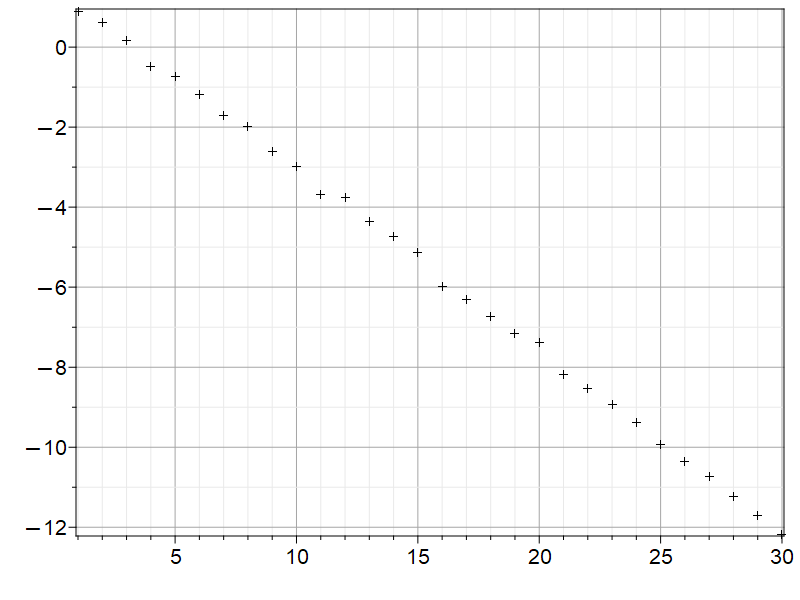

In [10]:
plot( [seq(j,j=1..last)],
      [seq(log[10](abs(err[j])),j=1..last)] , 
 style=point, symbol=cross, gridlines );

In [11]:
err[last-3..last], normF, tol*normF;

With this tolerance, the errors from Matlab are similar, but not quite the same: 
     1.807265448405815e-11
     6.010303366110747e-12
     1.949773675846700e-12
     7.123190925995004e-13

In [12]:
aaw := Vector( aa[1..last], datatype=dt ):
ssw := Vector( ss[1..last], datatype=dt ):
zzw := Vector( zz[1..last], datatype=dt ):
phiw := Vector( phi[1..last], datatype=dt ):
ntest := 100*nsamples:
stest := Vector( ntest, i -> -sqrt(2.0) + 2*sqrt(2.0)*i/(ntest+1), datatype=dt ):
xtest := Vector( ntest, i -> -exp(-1)*(1-stest[i]^2/2), datatype=dt ):
wtest := Vector(ntest, datatype=dt ):
tmp := Vector(ntest, datatype=dt ):
CodeTools:-Usage( evalcfrac_compiled( aaw, zzw, ssw, stest, wtest, last, ntest ) ):

memory used=1.28KiB, alloc change=0 bytes, cpu time=15.00ms, real time=14.00ms, gc time=0ns

In [13]:
err := Vector( ntest, i -> (xtest[i] - wtest[i]*exp(wtest[i]))):

kilobytes used=21661, alloc=14384, time=2.64

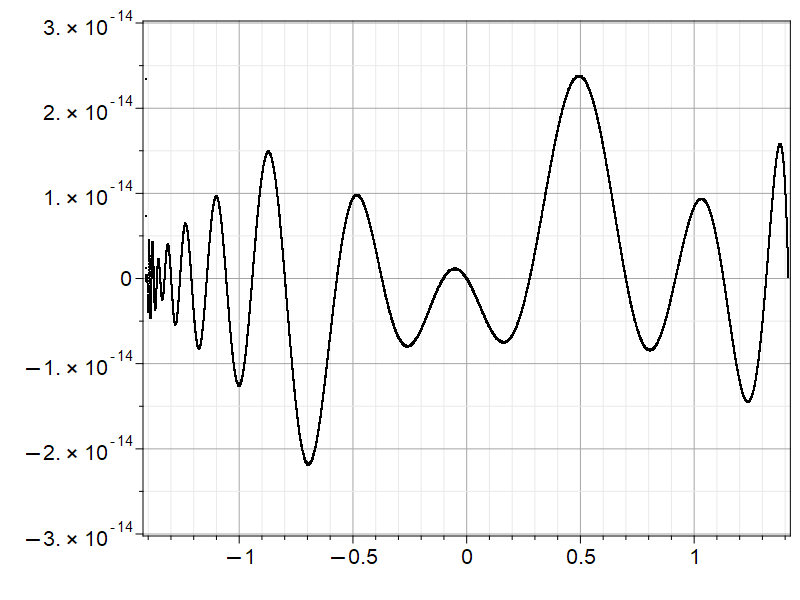

In [14]:
plots[pointplot]( stest, err, style=point, view=[default, -3.e-14..3.e-14], 
                  symbol=point, gridlines);